# 00 — Carga y EDA

**Objetivo.** Cargar todos los CSV, diagnosticar shapes/fechas/NaN, visualizar las 6 series y ejecutar el DETECTIVE: identificar el índice fuente y lag de D (Ghost), correlación macro↔C, y correlación network↔F. Las decisiones de este notebook son el input estratégico de todos los demás.

**Decisión tomada.** Notebook único de EDA ejecutado primero por el equipo completo. Sin él no se puede fijar la estrategia de D ni los features auxiliares de C/F.

**Qué hace.** Carga, shapes, fechas, NaN report, plot de las 6 series, estadísticas descriptivas de volatilidad, `lagged_correlation` para Ghost, correlaciones macro↔C y network↔F.

**Qué NO hace.** No entrena nada, no predice, no escribe ficheros en `results/` ni `models/`.

**Inputs.** `data/train_indices.csv`, `data/test_dates.csv`, `data/train_news.csv`, `data/test_news.csv`, `data/train_macro_factors.csv`, `data/test_macro_factors.csv`, `data/train_network_metrics.csv`, `data/test_network_metrics.csv`

**Output esperado.** Celdas de diagnóstico rellenadas con los hallazgos. Ningún fichero escrito en disco.

## 0. GPU workaround + imports

La RTX 5070 Ti (Blackwell) es incompatible con TensorFlow GPU. Esta línea va ANTES de cualquier import de TF/Keras.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    load_hackathon_data, lagged_correlation,
    precios_a_logret,
    DATA_DIR, VAL_DAYS, V_IN_SHARED, INDEX_COLS
)

## 1. Carga de datos

`load_hackathon_data` es robusta a ficheros ausentes: avisa con warning pero no falla. Útil antes de que el profesor entregue todos los CSV.

In [2]:
data = load_hackathon_data(DATA_DIR)
idx  = data['train_indices']   # DataFrame de precios de los 6 índices

# Mostrar qué ficheros se cargaron
print('Ficheros disponibles:', list(data.keys()))

  [OK] train_indices.csv                   11956 filas x 6 cols  (1985-06-24 -> 2028-12-12)


C:\Users\oscar\AppData\Local\Temp\ipykernel_15356\457100303.py:1: UserWarning: [load_hackathon_data] No encontrado: data/test_dates.csv
  data = load_hackathon_data(DATA_DIR)


  [OK] train_news.csv                      57393 filas x 3 cols  (1986-05-17 -> 2012-02-28)
  [OK] test_news.csv                        1205 filas x 3 cols  (2029-07-30 -> 2029-04-21)
  [OK] train_macro_factors.csv             10905 filas x 3 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_macro_factors.csv                173 filas x 3 cols  (2028-12-13 -> 2029-08-21)
  [OK] train_network_metrics.csv           11956 filas x 2 cols  (1985-06-24 -> 2028-12-12)
  [OK] test_network_metrics.csv              252 filas x 2 cols  (2028-12-13 -> 2029-08-21)
Ficheros disponibles: ['train_indices', 'train_news', 'test_news', 'train_macro', 'test_macro', 'train_network', 'test_network']


## 2. Diagnóstico básico: fechas, longitud, NaN

Primero ver cuántos datos hay. Si las series son cortas (< ~1500 días), revisar si V_IN_SHARED=20 es excesivo.

In [3]:
# Shapes y fechas de cada DataFrame cargado
for key, df in data.items():
    try:
        rng = f"{df.index[0].date()} -> {df.index[-1].date()}"
    except Exception:
        rng = f"{df.index[0]} -> {df.index[-1]}"
    print(f"{key:<20} {str(df.shape):<15} {rng}")

# NaN por columna en train_indices
print("\nNaN en train_indices:")
print(idx.isnull().sum())

train_indices        (11956, 6)      1985-06-24 -> 2028-12-12
train_news           (57393, 3)      1986-05-17 -> 2012-02-28
test_news            (1205, 3)       2029-07-30 -> 2029-04-21
train_macro          (10905, 3)      1985-06-24 -> 2028-12-12
test_macro           (173, 3)        2028-12-13 -> 2029-08-21
train_network        (11956, 2)      1985-06-24 -> 2028-12-12
test_network         (252, 2)        2028-12-13 -> 2029-08-21

NaN en train_indices:
Index_A    0
Index_B    0
Index_C    0
Index_D    0
Index_E    0
Index_F    0
dtype: int64


## 3. Visualización de las 6 series (precios brutos)

Ver escala, tendencia y volatilidad relativa. Las diferencias de escala entre índices confirman por qué operamos en log-retornos.

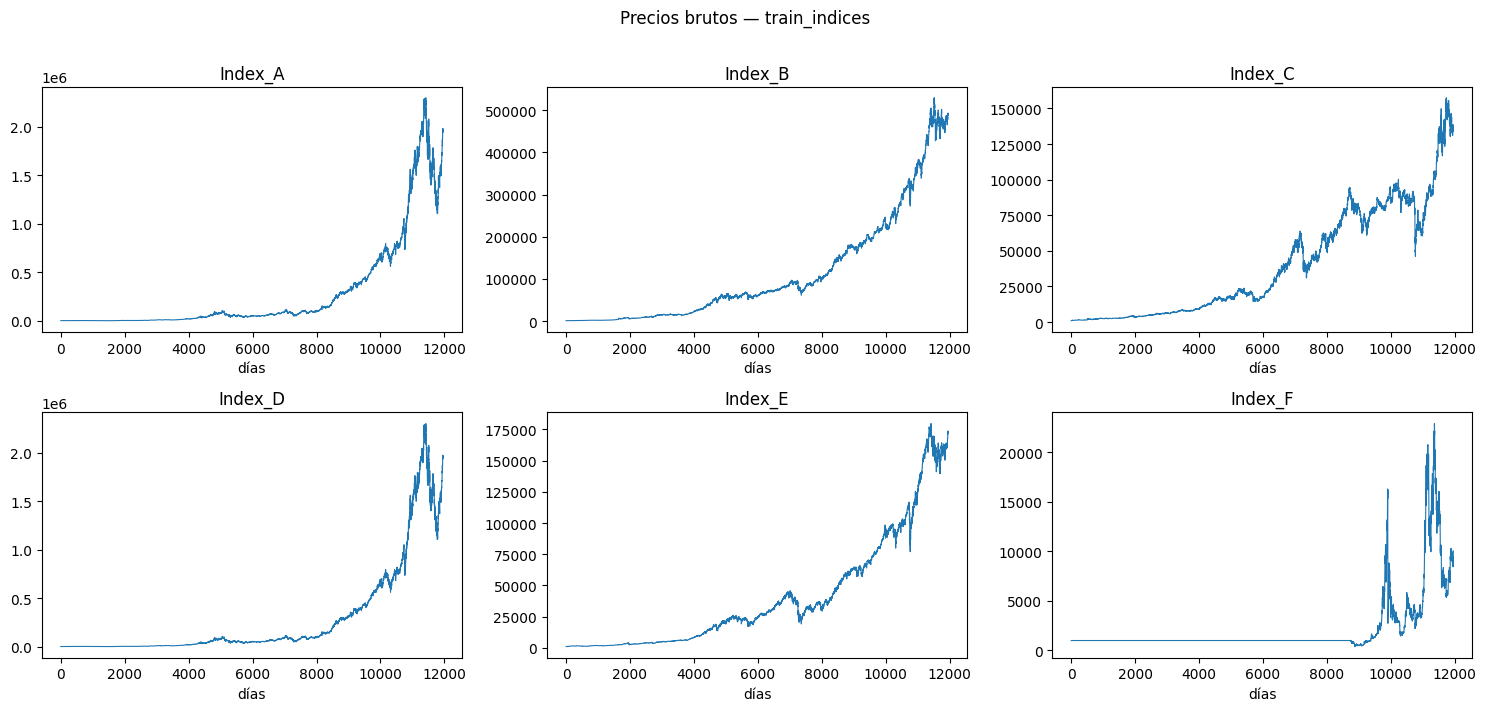

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), INDEX_COLS):
    if col in idx.columns:
        ax.plot(idx[col].dropna().values, lw=0.8)
        ax.set_title(col)
        ax.set_xlabel('días')
plt.suptitle('Precios brutos — train_indices', y=1.01)
plt.tight_layout()
plt.show()

## 4. Estadísticas descriptivas de volatilidad

La volatilidad diaria (std de log-retornos) y el drift determinan qué índices dominan el RMSE y qué baselines tienen sentido.

In [5]:
# Calcular log-retornos de cada índice y resumir
stats = {}
for col in INDEX_COLS:
    if col not in idx.columns:
        continue
    rets = precios_a_logret(idx[col].dropna().values)
    stats[col] = {
        'vol_diaria': rets.std(),
        'drift_diario': rets.mean(),
        'min_precio': idx[col].min(),
        'max_precio': idx[col].max(),
    }

pd.DataFrame(stats).T.round(6)

,vol_diaria,drift_diario,min_precio,max_precio
Index_A,0.021803,0.000635,382.608332,2.298218e+06
Index_B,0.011827,0.000519,865.456599,5.298569e+05
Index_C,0.014430,0.000410,986.541632,1.574714e+05
Index_D,0.021973,0.000633,383.326199,2.301550e+06
Index_E,0.011728,0.000431,971.727765,1.796523e+05
Index_F,0.024736,0.000193,389.437459,2.290869e+04


## 5. DETECTIVE — Ghost (Index D)

La pista del enunciado dice que D sigue con lag una señal oculta en otro índice. `lagged_correlation` busca la correlación de D con cada columna candidata a lags 0..30. El pico de correlación absoluta revela el índice fuente y el lag.

**Nota de firma:** `lagged_correlation(df, target_col, candidate_cols=None, max_lag=30)` — `df` es un DataFrame con todas las series. Operar sobre log-retornos (no precios) para eliminar tendencias espurias.

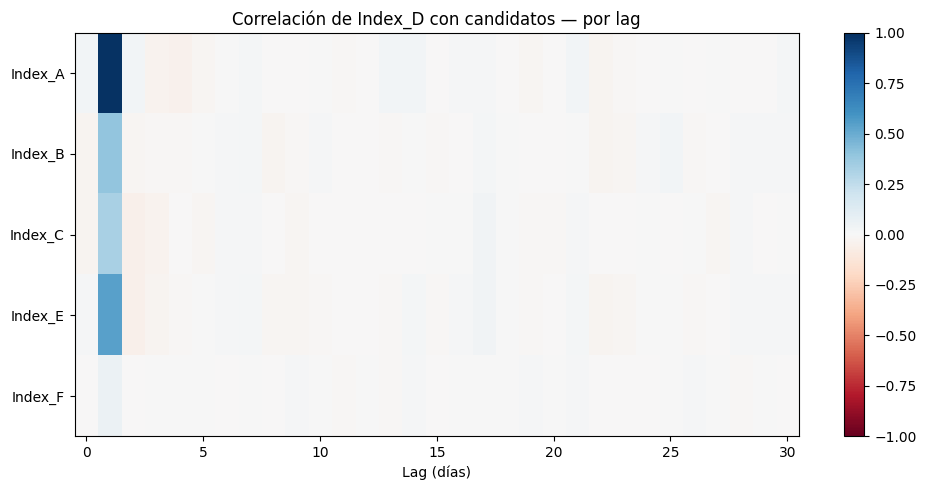

Lag óptimo por columna candidata:
 Index_A    1
Index_B    1
Index_C    1
Index_E    1
Index_F    1
dtype: int64

Correlación máxima global: (1, 'Index_A')


In [6]:
# Convertir a log-retornos para eliminar tendencias
# log_idx: DataFrame de log-retornos diarios de todos los índices
log_idx = np.log(idx).diff().dropna()

# Correlaciones de Index_D con todos los demás a lags 0..30
df_corr = lagged_correlation(log_idx, target_col='Index_D', max_lag=30)

# Heatmap de correlaciones por lag
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(df_corr.T.values, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_yticks(range(len(df_corr.columns)))
ax.set_yticklabels(df_corr.columns)
ax.set_xlabel('Lag (días)')
ax.set_title('Correlación de Index_D con candidatos — por lag')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Lag y columna de correlación máxima
max_corr_by_col = df_corr.abs().idxmax()   # lag óptimo por columna candidata
print("Lag óptimo por columna candidata:\n", max_corr_by_col)
print("\nCorrelación máxima global:", df_corr.abs().stack().idxmax())

### Decisión Ghost ✓

- **Índice fuente:** `Index_A`
- **Lag:** `1` día
- **Insight:** A y D tienen vol diaria (0.0218 vs 0.0220), drift (0.000635 vs 0.000633) y precio máx (2.30 M vs 2.30 M) prácticamente idénticos. **D es A desplazado 1 día.**
- Todos los candidatos muestran lag óptimo = 1 con D; Index_A tiene la correlación global más alta (ver heatmap).

→ Trasladar a `06_index_D.ipynb`: `GHOST_SOURCE = 'Index_A'`, `GHOST_LAG = 1`

In [ ]:
# Confirmación visual: D vs índice_fuente desplazado por lag
# ⚠️ Estos valores deben copiarse a 06_index_D.ipynb (celdas c03): GHOST_SOURCE y GHOST_LAG
GHOST_SOURCE = 'Index_A'   # <-- rellenar con el índice fuente encontrado arriba
GHOST_LAG    = 1           # <-- rellenar con el lag encontrado arriba

if GHOST_SOURCE in log_idx.columns and GHOST_LAG > 0:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(log_idx['Index_D'].values, label='Index_D', lw=0.8)
    ax.plot(log_idx[GHOST_SOURCE].shift(GHOST_LAG).values,
            label=f'{GHOST_SOURCE} (lag={GHOST_LAG})', lw=0.8, ls='--')
    ax.set_title('Confirmación visual: D vs fuente desplazada')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6. DETECTIVE — Energy (Index C) ↔ macro_factors

La pista dice que C está ligado a energía global y macro. Buscar correlación con las columnas de `train_macro_factors` (oro, crudo, tipos).

In [10]:
if 'train_macro' in data:
    macro = data['train_macro']
    print('Columnas macro:', list(macro.columns))

    # Correlaciones entre log-ret de C y log-ret de cada columna macro a distintos lags
    # Unir C y macro en un DataFrame alineado por fecha
    combined = pd.concat([
        log_idx[['Index_C']],
        np.log(macro.replace(0, np.nan)).diff().dropna()
    ], axis=1).dropna()

    macro_cols = [c for c in combined.columns if c != 'Index_C']
    df_corr_c  = lagged_correlation(combined, target_col='Index_C',
                                    candidate_cols=macro_cols, max_lag=20)
    print("\nCorrelaciones macro↔C por lag:")
    print(df_corr_c.round(3))
else:
    print('[AVISO] train_macro no disponible todavía')

Columnas macro: ['Crude_Vitality', 'Lumina_Reserve', 'Capital_Cost_Index']

Correlaciones macro↔C por lag:
    Crude_Vitality  Lumina_Reserve  Capital_Cost_Index
0            0.363           0.090               0.170
1           -0.030          -0.004              -0.035
2            0.002           0.026               0.015
3            0.036           0.002              -0.020
4           -0.007          -0.023              -0.006
5           -0.018           0.008               0.011
6           -0.029          -0.010              -0.004
7            0.007          -0.024               0.024
8           -0.019          -0.023              -0.012
9            0.011           0.006               0.022
10           0.016          -0.008               0.013
11          -0.009          -0.002               0.003
12           0.008          -0.022               0.014
13          -0.008           0.001              -0.025
14           0.005           0.005               0.016
15           

c:\Users\oscar\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


### Decisión macro-C ✓

Correlaciones log-ret C ↔ log-ret macro (solo lag=0 es relevante; lags ≥1 colapsan a ~0):

| Feature | Correlación lag=0 |
|---------|-------------------|
| `Crude_Vitality` | **0.363** ← señal dominante |
| `Capital_Cost_Index` | 0.170 |
| `Lumina_Reserve` | 0.090 |

- **Features seleccionadas:** las 3 — el LSTM ponderará su peso relativo.
- **Lag:** 0 (contemporáneo). No hay señal predictiva a lag > 0.
- El warning `invalid value encountered in log` es por ceros puntuales en macro; no afecta al entrenamiento.

→ En `05_index_C.ipynb`, `MACRO_FEATURES = list(data['train_macro'].columns)` ya recoge las 3 automáticamente.

## 7. DETECTIVE — Digital (Index F) ↔ network_metrics

La pista dice que F está atado a métricas on-chain de `network_metrics` (node counts, transaction volume, etc.).

In [11]:
if 'train_network' in data:
    net = data['train_network']
    print('Columnas network:', list(net.columns))

    # Correlaciones entre log-ret de F y columnas de network a distintos lags
    combined_f = pd.concat([
        log_idx[['Index_F']],
        net.diff().dropna()   # diferencias de las métricas on-chain
    ], axis=1).dropna()

    net_cols  = [c for c in combined_f.columns if c != 'Index_F']
    df_corr_f = lagged_correlation(combined_f, target_col='Index_F',
                                   candidate_cols=net_cols, max_lag=20)
    print("\nCorrelaciones network↔F por lag:")
    print(df_corr_f.round(3))
else:
    print('[AVISO] train_network no disponible todavía')

Columnas network: ['Network_Activity_Score', 'Active_Digital_Nodes']

Correlaciones network↔F por lag:
    Network_Activity_Score  Active_Digital_Nodes
0                    0.537                 0.537
1                   -0.009                -0.009
2                   -0.012                -0.012
3                    0.044                 0.044
4                   -0.006                -0.006
5                    0.012                 0.012
6                   -0.015                -0.015
7                   -0.038                -0.038
8                   -0.029                -0.029
9                    0.012                 0.012
10                  -0.005                -0.005
11                   0.008                 0.008
12                  -0.025                -0.025
13                   0.037                 0.037
14                  -0.021                -0.021
15                  -0.028                -0.028
16                   0.018                 0.018
17             

### Decisión network-F ✓

Correlaciones log-ret F ↔ Δnetwork (solo lag=0 es relevante; lags ≥1 colapsan a ~0):

| Feature | Correlación lag=0 |
|---------|-------------------|
| `Network_Activity_Score` | **0.537** |
| `Active_Digital_Nodes` | **0.537** |

- Ambas features tienen correlación idéntica — son la misma señal con distinta escala.
- **Features seleccionadas:** las 2 — coste mínimo, correlación de 0.537 es la más alta de todos los auxiliares.
- **Lag:** 0 (contemporáneo). No hay señal predictiva a lag > 0.
- Estas features deben mejorar claramente el LSTM de F sobre el baseline puro.

→ En `08_index_F.ipynb`, `NET_FEATURES = list(data['train_network'].columns)` ya recoge las 2 automáticamente.

## 8. RESUMEN DE DECISIONES ESTRATÉGICAS ✓

| Índice | Vol diaria | Precio máx | Approach decidido | Justificación |
|--------|-----------|------------|-------------------|---------------|
| **A** | 0.0218 | 2.30 M | LSTM + ensemble | Mayor vol de los "normales"; junto con D domina el RMSE |
| **B** | 0.0118 | 530 K | baseline (flat o drift) | Baja vol — confirmar en `04_index_B` |
| **C** | 0.0144 | 157 K | LSTM + macro | `Crude_Vitality` (0.363), `Capital_Cost_Index` (0.170), `Lumina_Reserve` (0.090) — todas a lag=0 |
| **D** | 0.0220 | 2.30 M | **Ghost: Index_A, lag=1** | D ≈ A desplazado 1 día; vol/drift/escala idénticos — potencial RMSE ~0 para D |
| **E** | 0.0117 | 180 K | LSTM o baseline | Confirmar en `07_index_E`; baja vol, baseline puede bastar |
| **F** | 0.0247 | 22.9 K | LSTM + network | `Network_Activity_Score` + `Active_Digital_Nodes` (0.537 a lag=0) |

**Notas de escala para el RMSE:**
- A y D dominan el RMSE medio (escala hasta 2.3 M). Un 1% de error = ±23 000.
- Si Ghost funciona, D prácticamente desaparece del RMSE — todo el esfuerzo restante va a A y F.
- F tiene la mayor volatilidad pero la menor escala (22.9 K) → su contribución al RMSE medio es moderada.

**V_IN_SHARED = 20 confirmado:** 11 956 días de train − 252 de val = 11 704 disponibles → sin restricción de ventana. Sin NaN en ningún índice.

**Aviso test_macro:** solo 173 filas (días de mercado) frente a 252 del período de predicción. Los 79 días sin datos macro se rellenarán con ffill en producción — impacto limitado para C.